# **Colombia**

República de Colombia, es un país soberano situado en la región noroccidental de América del Sur.

El país es travesado por la cordillera de los Andes y la llanura amazónica, es el único país de América del Sur con costas sobre los océanos Atlántico y Pacífico. Por estar muy cerca del Ecuador en una baja latitud, todos los climas que se presentan en Colombia son isotérmicos, es decir, sin amplitud térmica relevante a lo largo del año.

Por la dinámica del territorio el clima está relacionado con las estaciones según la precipitación (estación seca y estación lluviosa).

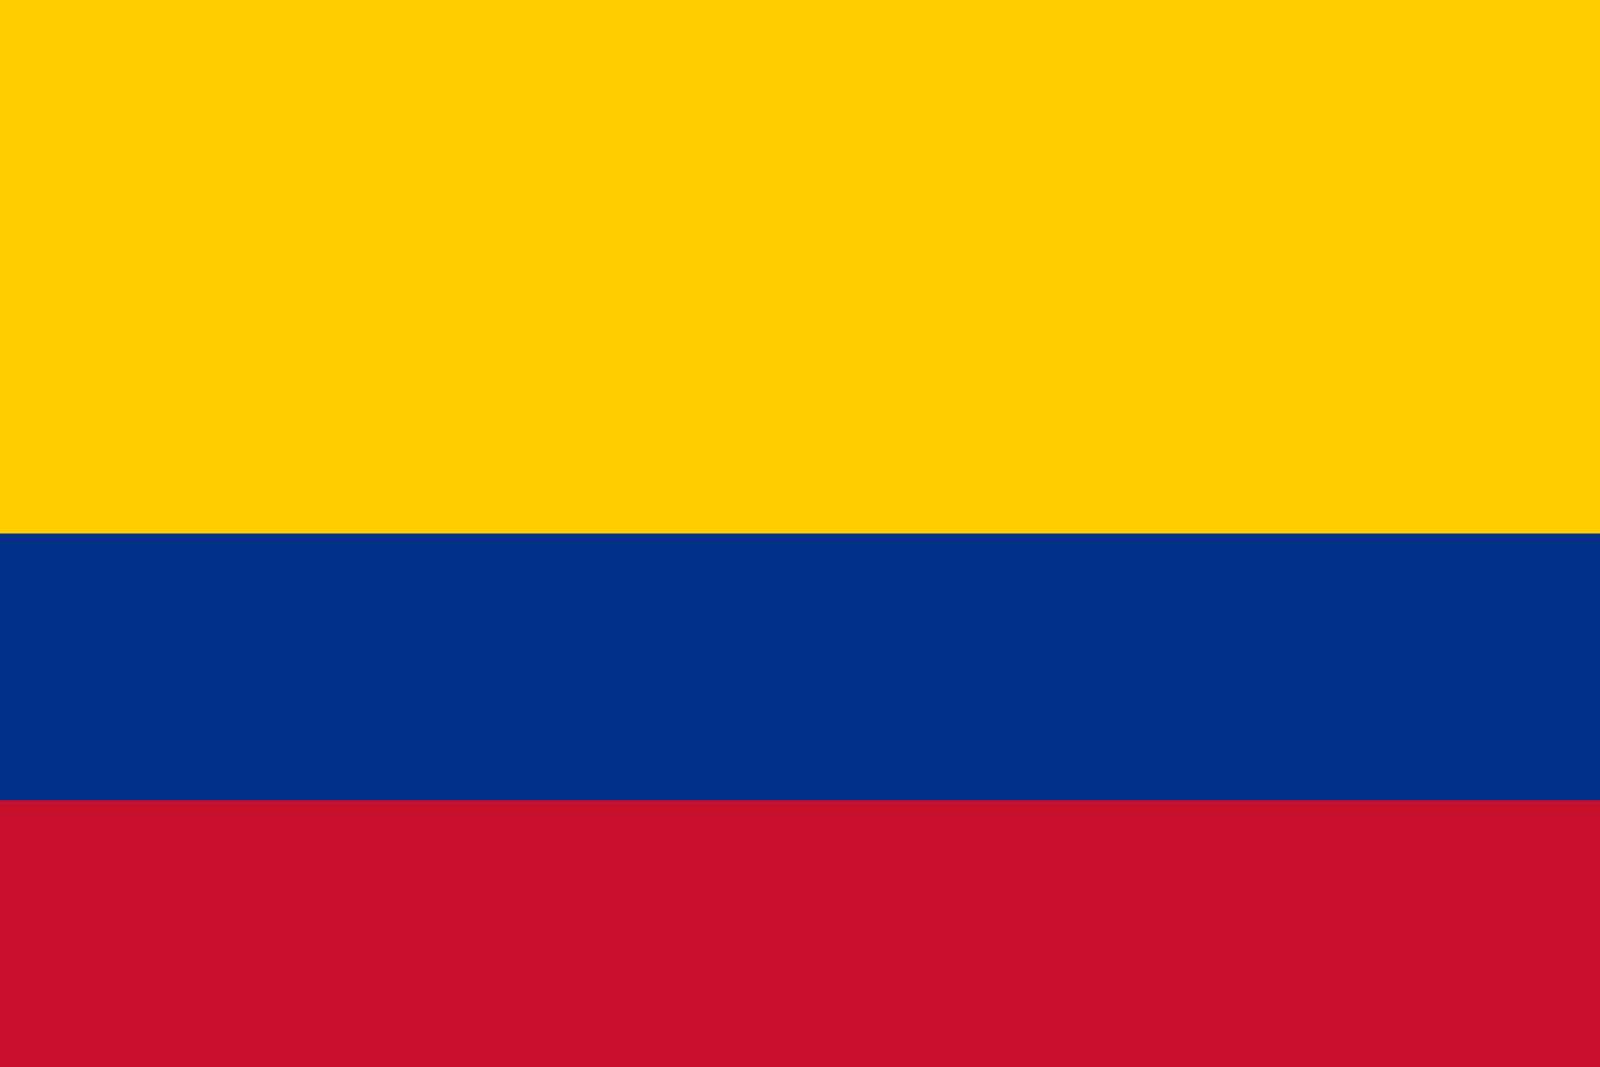

> Para el análisis se cuenta con 947,790 registros correspondientes a casos ocurridos en alguno de los 32 municipios y el distrito capital de la república de Colombia, representado en 19 variables, en el periodo del año 2013 al año 2023.

__________

In [1]:
# [Configuración] Importar librerías

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
from statsmodels.graphics.tsaplots import plot_acf

# Geoespacial
import geopandas as gpd
from libpysal.weights import Queen
import libpysal
from esda.moran import Moran, Moran_Local

# Estadística clásica y no paramétrica
from scipy import stats
from scipy.stats import chi2_contingency, kruskal, shapiro
import scikit_posthocs as sp  # Pruebas post-hoc como Dunn

# Series temporales y detección de rupturas
import ruptures as rpt
from pymannkendall import original_test  # Tendencias en series temporales

In [23]:
# [Configuración] Leer data
df = pd.read_csv(r"C:\Users\Hp\DENGUE\DATA\Data_Colombia.csv")

# Leer shapefile
gdf = gpd.read_file("Mapas/Departamento/MGN_ADM_DPTO_POLITICO.shp", encoding='utf_8')
gdf = gdf.rename(columns={'dpto_cnmbr': 'departamento'})

semanas = pd.read_csv("Resumen/consolidado_colombia.csv")

casos = pd.read_csv("Resumen/casos_dep_colombia.csv")

poblacion = pd.read_csv("Poblacion/Poblacion_nacional.csv", encoding="latin_1")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947790 entries, 0 to 947789
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype 
---  ------                 --------------   ----- 
 0   sexo                   947790 non-null  object
 1   edad_años              947790 non-null  int64 
 2   ciclo_vital            947790 non-null  object
 3   grupo_etnico           947790 non-null  object
 4   regimen_salud          947790 non-null  object
 5   evento                 947790 non-null  object
 6   tipo_caso              947790 non-null  object
 7   hospitalizacion        947790 non-null  object
 8   desenlace              947790 non-null  object
 9   año                    947790 non-null  int64 
 10  semana                 947790 non-null  int64 
 11  periodo                947790 non-null  int64 
 12  fecha_inicio_sintomas  947737 non-null  object
 13  fecha_consulta         947697 non-null  object
 14  fecha_hospitalizacion  400804 non-null  object
 15  

In [8]:
# [] Convertir fechas a DateTime
columnas_fecha = ["fecha_consulta", "fecha_inicio_sintomas", "fecha_notificacion", "fecha_nacimiento", "fecha_hospitalizacion"]

for col in columnas_fecha:
    df[col] = df[col].replace(["--", "  -   -", "-", " "], pd.NA)
    df[col] = pd.to_datetime(df[col], format='mixed')
    print(f"Columna '{col}' convertida a datetime.")

Columna 'fecha_consulta' convertida a datetime.
Columna 'fecha_inicio_sintomas' convertida a datetime.
Columna 'fecha_notificacion' convertida a datetime.
Columna 'fecha_nacimiento' convertida a datetime.
Columna 'fecha_hospitalizacion' convertida a datetime.


In [9]:
# [] Valores nulos por variable
faltantes = df.isnull().sum()
print("Valores faltantes por variable: \n")
print(faltantes[faltantes > 0])

Valores faltantes por variable: 

fecha_inicio_sintomas        53
fecha_consulta               93
fecha_hospitalizacion    546986
fecha_nacimiento          30088
dtype: int64


## **1. Descriptivo de variables**

In [10]:
# [Función] Descripción de variables categóricas

def describir_categorica(columna, col_evento="evento"):
    tabla = pd.DataFrame({
        "Conteo": columna.value_counts(dropna=False),
        "Proporción": columna.value_counts(normalize=True, dropna=False).round(4)
    })

    tabla.index = tabla.index.map(lambda x: "NaN" if pd.isna(x) else x)
    crosstab_evento = pd.crosstab(df[columna.name], df[col_evento])
    tabla_completa = tabla.join(crosstab_evento)

    # Agregar proporciones específicas para 'Clasico' y 'Grave'
    if "Clasico" in crosstab_evento.columns:
        tabla_completa["Prop_Clasico"] = (tabla_completa["Clasico"] / tabla_completa["Conteo"]).round(4)
    else:
        tabla_completa["Prop_Clasico"] = 0
    if "Grave" in crosstab_evento.columns:
        tabla_completa["Prop_Grave"] = (tabla_completa["Grave"] / tabla_completa["Conteo"]).round(4)
    else:
        tabla_completa["Prop_Grave"] = 0

    print(f"\n📌 Variable: {columna.name}")
    print(tabla_completa)
    print("\n-----------------------------------")

### 2.1 Variables demográficas

In [11]:
print("DESCRIPCIÓN DE VARIABLES CATEGÓRICAS")
describir_categorica(df["ciclo_vital"])
describir_categorica(df["sexo"])
describir_categorica(df["grupo_etnico"])
describir_categorica(df["regimen_salud"])


DESCRIPCIÓN DE VARIABLES CATEGÓRICAS

📌 Variable: ciclo_vital
                  Conteo  Proporción  Clasico  Grave  Prop_Clasico  Prop_Grave
ciclo_vital                                                                   
Adulto            354522      0.3741   350408   4114        0.9884      0.0116
Adolescencia      268126      0.2829   263627   4499        0.9832      0.0168
Infancia          154053      0.1625   150959   3094        0.9799      0.0201
Primera infancia  101852      0.1075   100013   1839        0.9819      0.0181
Adulto mayor       55679      0.0587    54696    983        0.9823      0.0177
Menor de 1 año      9056      0.0096     8679    377        0.9584      0.0416
Ancianidad          4497      0.0047     4391    106        0.9764      0.0236
Desconocido            5      0.0000        5      0        1.0000      0.0000

-----------------------------------

📌 Variable: sexo
           Conteo  Proporción  Clasico  Grave  Prop_Clasico  Prop_Grave
sexo                 

De acuerdo a los registros, la población infectada por dengue en Colombia se encuentra, en mayor medida, en edad adulta (37.4%) o adolescente (28.2%). De los demás grupos, los menores de 1 año y ancianidad son los que proporcionalmente son los más afectados por el dengue grave.

El sexo de los pacientes se distribuye de forma equilibrada, siento el 52.3% masculinos. La pertenencia a grupos étnicas indica que solo el 5.08% pertenecen a algún grupo; cabe detallar que el más del 20% de los casos para población Indígena y Rom corresponden a dengue grave.

La afiliación a regimen de salud de la población es en su mayoría a regimen subsidiado (46.1%) o contributivo (44.4%), sin embargo, los pacientes no asegurados tienen una alta proporción de casos graves.

In [12]:
# [Análisis] Edad de los pacientes
df_edad = df[df["ciclo_vital"] != "Menor de 1 año"].copy()

orden_ciclos_edad = [
    "Primera infancia",
    "Infancia",
    "Adolescencia",
    "Adulto",
    "Adulto mayor",
    "Ancianidad"
]

df_edad["ciclo_vital"] = pd.Categorical(
    df_edad["ciclo_vital"], 
    categories=orden_ciclos_edad, 
    ordered=True
)

def tabla_descriptiva(df, variable, grupo=None):
    """
    Genera una tabla descriptiva (media, mediana, DE, IQR, etc.)
    por grupos (ej. ciclo vital).
    """
    if grupo:
        desc = df.groupby(grupo, observed=True)[variable].agg(
            n = 'count',
            media = 'mean',
            mediana = 'median',
            sd = 'std',
            q25 = lambda x: np.percentile(x, 25),
            q75 = lambda x: np.percentile(x, 75),
            minimo = 'min',
            maximo = 'max'
        ).reset_index()
    else:
        desc = df[variable].agg(
            n = 'count',
            media = 'mean',
            mediana = 'median',
            sd = 'std',
            q25 = lambda x: np.percentile(x, 25),
            q75 = lambda x: np.percentile(x, 75),
            minimo = 'min',
            maximo = 'max'
        ).to_frame().T
    return desc.round(2)

tabla = tabla_descriptiva(df_edad, variable="edad_años", grupo="ciclo_vital")
tabla

,ciclo_vital,n,media,mediana,sd,q25,q75,minimo,maximo
0,Primera infancia,101852,2.37,2.0,1.19,1.0,3.0,1,4
1,Infancia,154053,7.08,7.0,1.40,6.0,8.0,5,9
2,Adolescencia,268126,13.99,14.0,2.77,12.0,16.0,10,19
3,Adulto,354522,34.87,33.0,11.16,25.0,43.0,20,59
4,Adulto mayor,55679,69.09,68.0,6.79,63.0,74.0,60,84
5,Ancianidad,4497,88.89,88.0,4.25,86.0,91.0,85,131


La edad de los pacientes, diferenciada entre grupos etarios, se distribuye de la siguiente manera: 

* Primera infancia [1-4 años]: Mayor concentración de edades al rededor de los 2 años.
* Infancia [5-9 años]: Edad concentrada entre los 6-8 años.
* Adolescencia [10-19 años]: Mayor cantidad de pacientes entre los 12-16 años.
* Adulto [20-59 años]: Mayoría de pacientes entre los 25-43 años.
* Adulto mayor [60 - 84 años]: Edades entre los 63-74 años.
* Ancianidad [85 -131 años]: Concentración de edades entre los 86-91 años. 

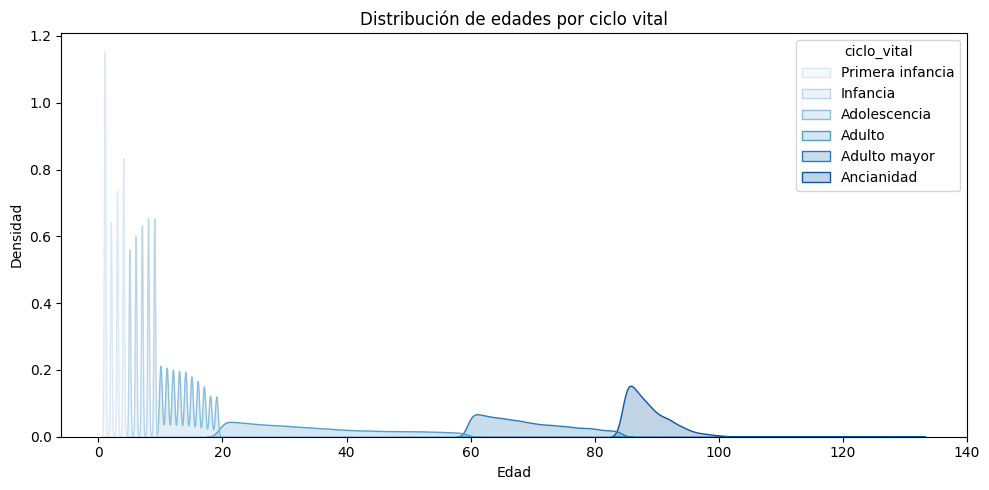

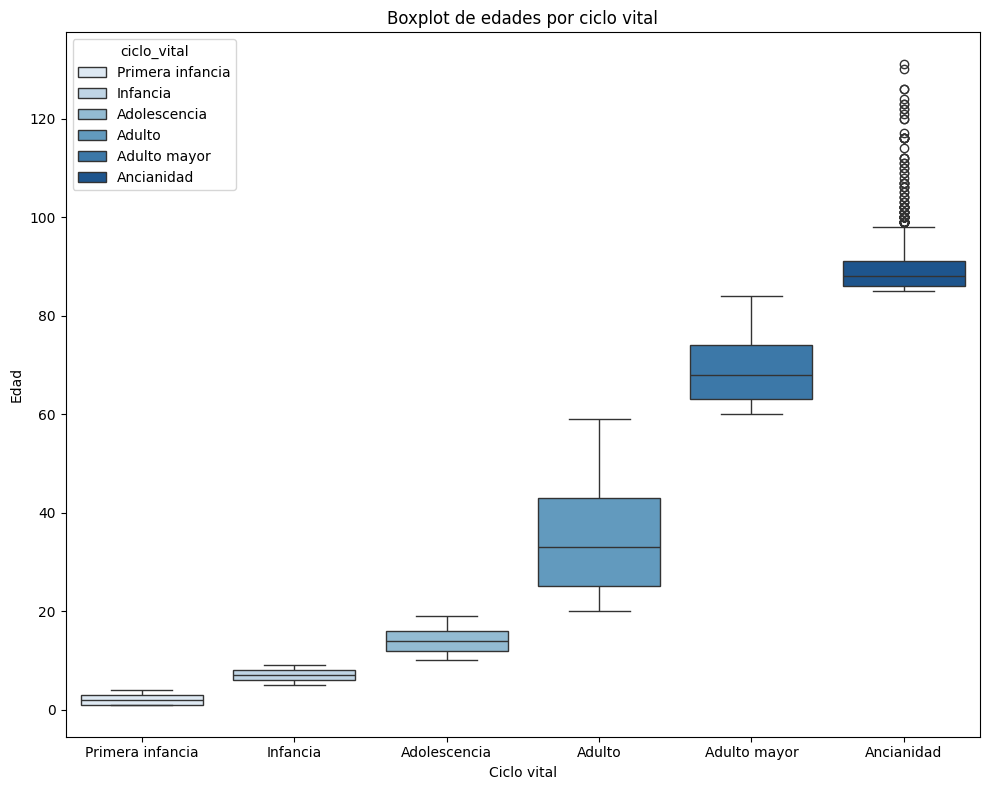

In [13]:
# [Gráfico] Distribución de edad
def graficos(df, variable, grupo):
    """
    Genera:
    1. Histograma + densidad global
    2. Densidad por ciclo vital
    3. Boxplot por ciclo vital
    """

    # --- 2. Densidad por ciclo vital ---
    plt.figure(figsize=(10,5))
    sns.kdeplot(data=df, x=variable, hue=grupo, common_norm=False, fill=True, palette="Blues")
    plt.title("Distribución de edades por ciclo vital")
    plt.xlabel("Edad")
    plt.ylabel("Densidad")
    plt.tight_layout()
    plt.show()

    # --- 3. Boxplot por ciclo vital ---
    plt.figure(figsize=(10,8))
    sns.boxplot(data=df, x=grupo, hue=grupo, y=variable, palette="Blues")
    plt.title("Boxplot de edades por ciclo vital")
    plt.xlabel("Ciclo vital")
    plt.ylabel("Edad")
    plt.tight_layout()
    plt.show()

graficos(df_edad, variable="edad_años", grupo="ciclo_vital")

Los gráficos representan la distribución de la edad, discriminada por grupos etarios, donde se evidencia que para las primeras etapas de la vida, la distribución de la edad de los pacientes es homogénea. La etapa adulta es la de mayor variabilidad, con un ligero sesgo positivo, lo que indica una mayor proporción de casos hacia los adultos mas jóvenes. Misma dinámica se aprecia para el grupo Adulto mayor y Ancianidad, en este último se presentan los casos de pacientes en edades atípicas. 

## Variables de evento

In [15]:
describir_categorica(df['evento'])
describir_categorica(df['tipo_caso'])
describir_categorica(df['hospitalizacion'])
describir_categorica(df['desenlace'])


📌 Variable: evento
         Conteo  Proporción  Clasico  Grave  Prop_Clasico  Prop_Grave
evento                                                               
Clasico  932778      0.9842   932778      0           1.0         0.0
Grave     15012      0.0158        0  15012           0.0         1.0

-----------------------------------

📌 Variable: tipo_caso
                       Conteo  Proporción  Clasico  Grave  Prop_Clasico  \
tipo_caso                                                                 
Probable               697800      0.7362   688277   9523        0.9864   
Conf. por laboratorio  241643      0.2550   236199   5444        0.9775   
Conf. por nexo           8347      0.0088     8302     45        0.9946   

                       Prop_Grave  
tipo_caso                          
Probable                   0.0136  
Conf. por laboratorio      0.0225  
Conf. por nexo             0.0054  

-----------------------------------

📌 Variable: hospitalizacion
                 C

El virus del dengue en su manifestación clásica tiene una representatividad del 98.4% (932,778 casos) en el país, frente al reducido conjunto del 1.6% (15,012) casos graves. 

En su mayoría, los casos fueron catalogados como probables (73.6%), el restante fue confirmado por laboratorio o nexo epidemiológico. La mayor parte de los pacientes (57.7%) no requirió hospitalización, aunque de los 400,806 pacientes hospitalizados, el 34.1% fue debido al dengue grave. 

La tasa de fallecidos es de solo 339, en su mayoría a causa del dengue grave. 

### 2.3 Variables espaciales

In [17]:
describir_categorica(df["area"])
describir_categorica(df['departamento'])


📌 Variable: area
                    Conteo  Proporción  Clasico  Grave  Prop_Clasico  \
area                                                                   
Cabecera municipal  779765      0.8227   767715  12050        0.9845   
Rural disperso       90096      0.0951    88575   1521        0.9831   
Centro Poblado       77929      0.0822    76488   1441        0.9815   

                    Prop_Grave  
area                            
Cabecera municipal      0.0155  
Rural disperso          0.0169  
Centro Poblado          0.0185  

-----------------------------------

📌 Variable: departamento
                                                    Conteo  Proporción  \
departamento                                                             
VALLE DEL CAUCA                                     159217      0.1680   
TOLIMA                                               81906      0.0864   
SANTANDER                                            77715      0.0820   
ANTIOQUIA              

In [20]:
# [Tabla] Casos por departamento
tabla_mun = df.groupby(["departamento", "año", "evento"]).size().reset_index(name="casos")


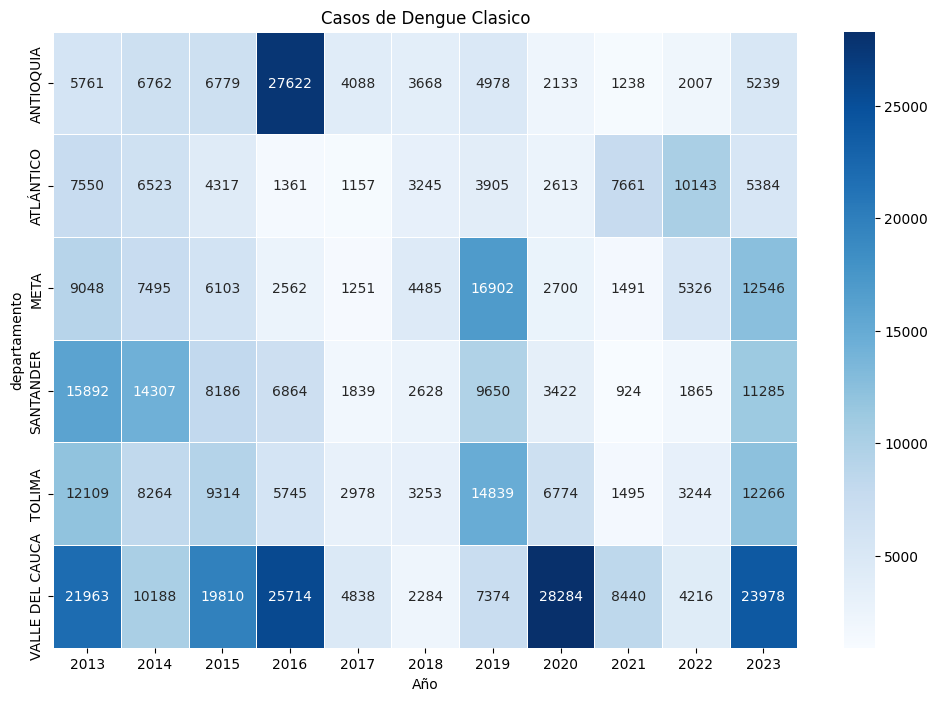

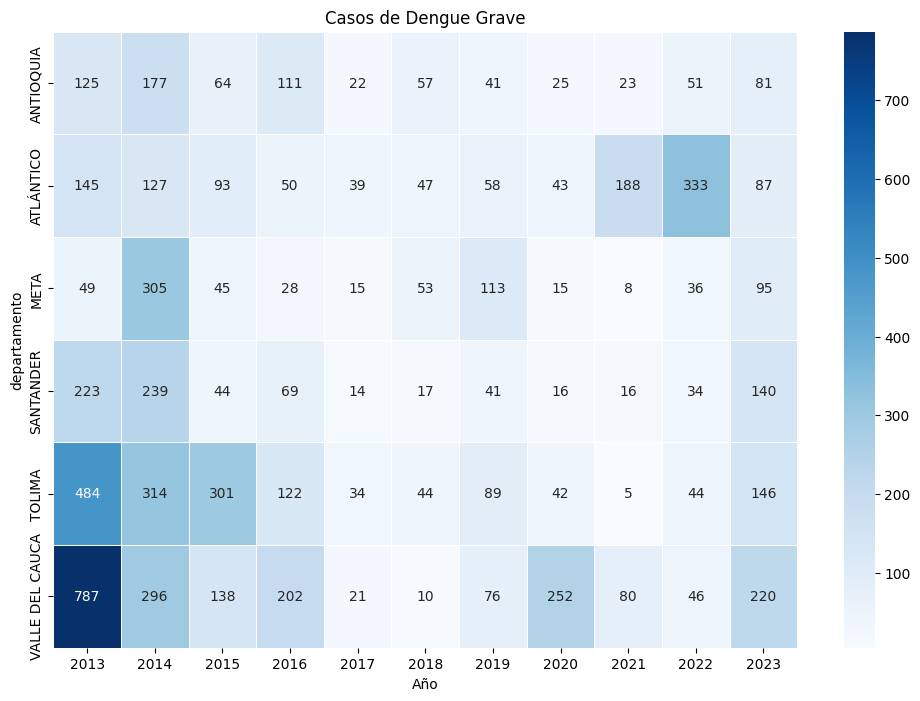

In [21]:
# [Gráfico] Tabla casos por departamento
totales_mun = tabla_mun.groupby("departamento")["casos"].sum()

departamentos_filtrados = totales_mun[totales_mun > 50000].index
tabla_filtrada = tabla_mun[tabla_mun["departamento"].isin(departamentos_filtrados)]

eventos = ["Clasico", "Grave"]

for evento in eventos:
    tabla_evento = tabla_filtrada[tabla_filtrada["evento"] == evento]

    # Crear tabla pivote
    pivot = tabla_evento.pivot_table(
        index="departamento", 
        columns="año", 
        values="casos", 
        fill_value=0
    ).astype(int)

    # Graficar
    plt.figure(figsize=(12,8))
    sns.heatmap(pivot, cmap="Blues", linewidths=0.5, annot=True, fmt="d")
    plt.title(f"Casos de Dengue {evento}")
    plt.xlabel("Año")
    plt.ylabel("departamento")
    plt.show()


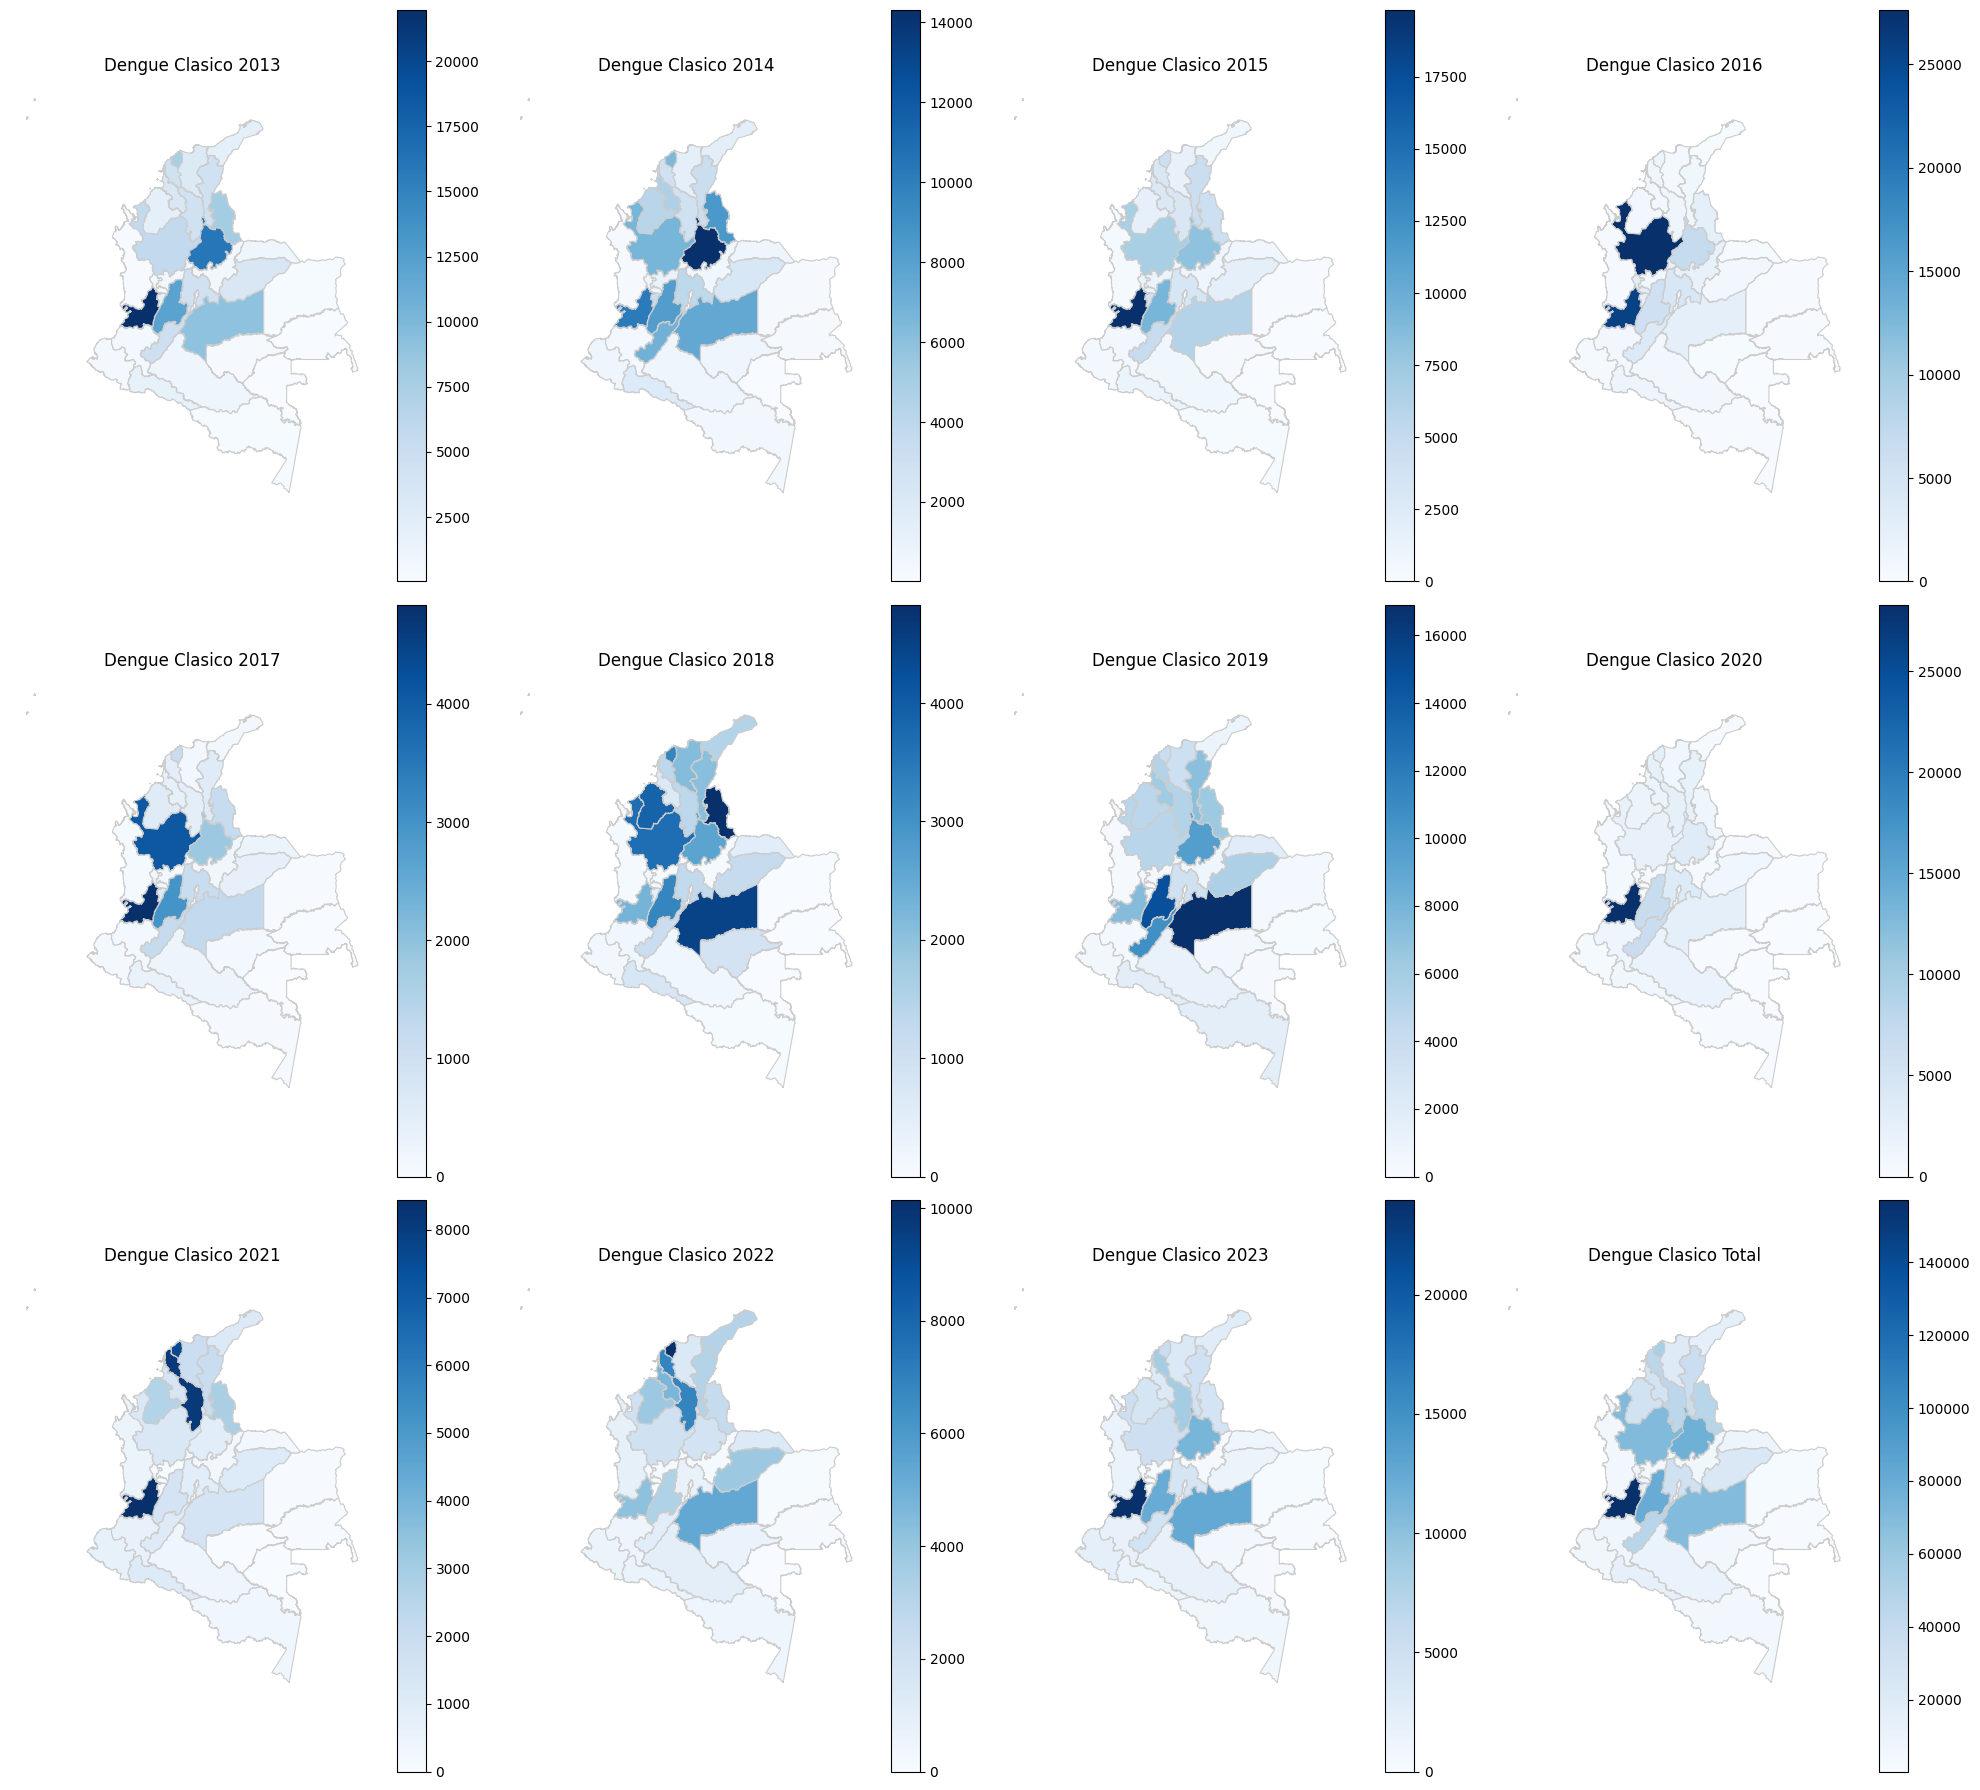

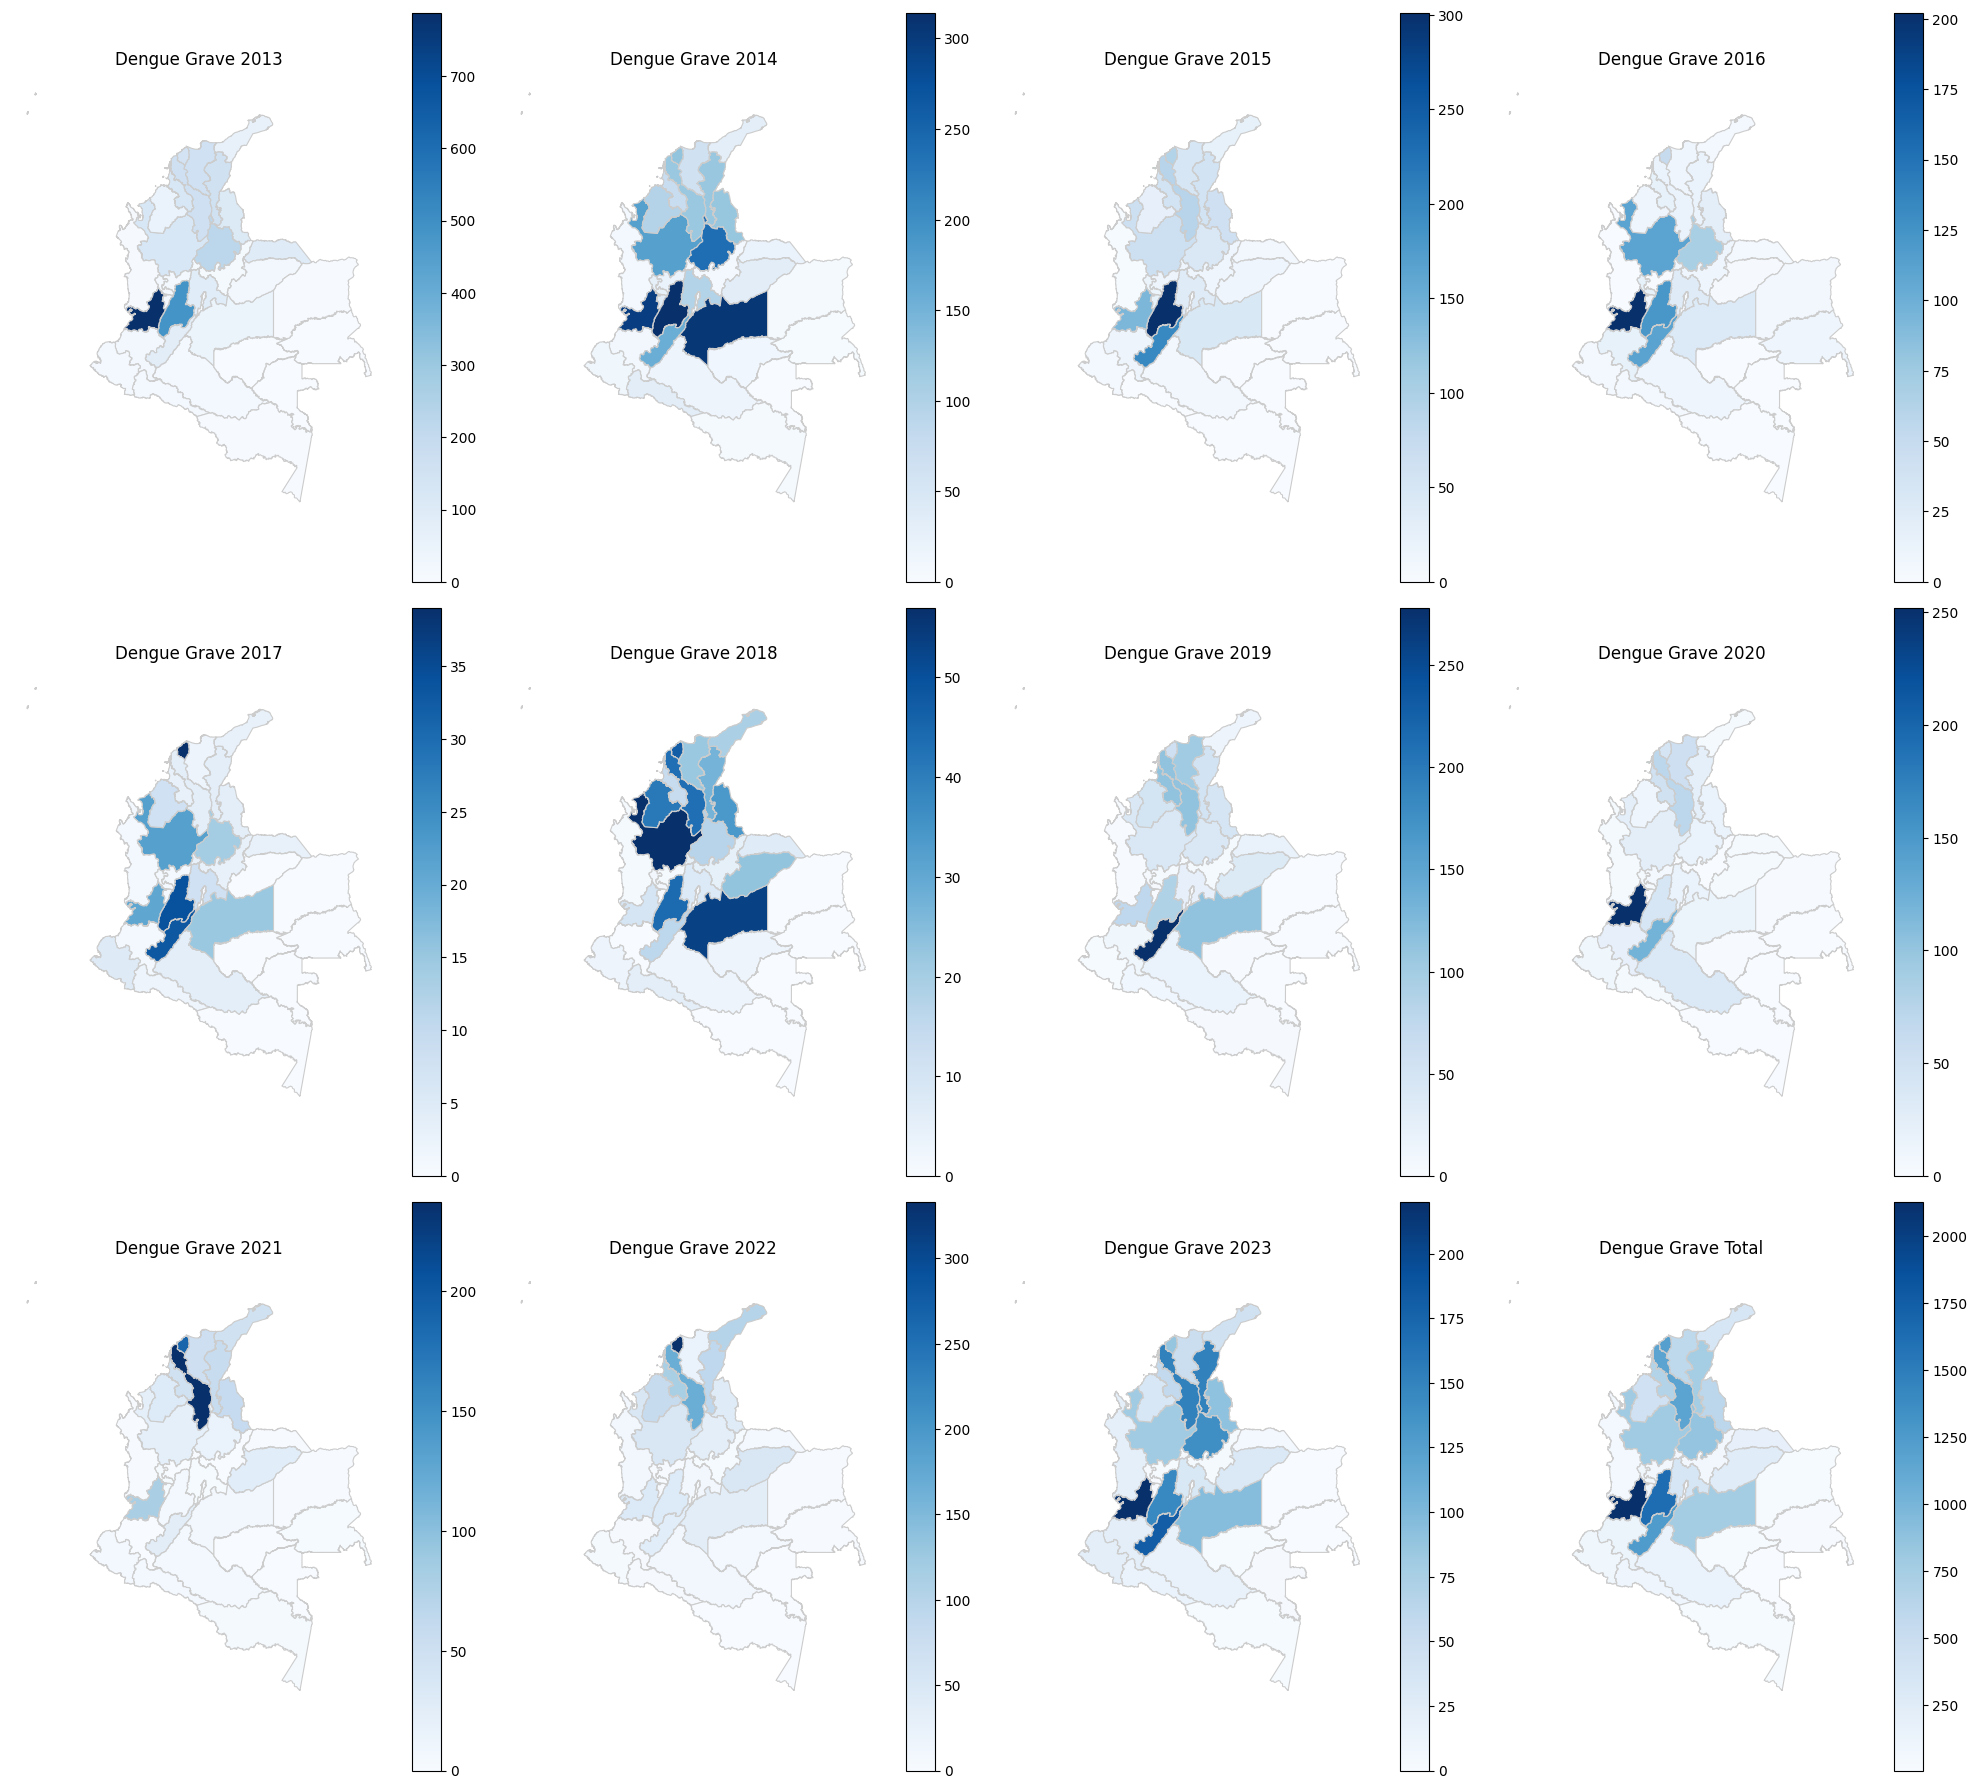

In [22]:
# [Gráfico] Mapa casos por departamento según evento

eventos = ["Clasico", "Grave"]

for evento in eventos:
    anios = sorted(df["año"].unique())
    n = len(anios) + 1  # años + total

    # Calcular número de filas y columnas dinámicamente
    columnas = 4
    filas = (n + columnas - 1) // columnas

    fig, axes = plt.subplots(filas, columnas, figsize=(5*columnas, 6*filas))
    axes = axes.flatten()

    # Mapas por año
    for i, anio in enumerate(anios):
        casos_anio = (
            df[(df["año"] == anio) & (df["evento"] == evento)]
            .groupby("departamento")
            .size()
            .reset_index(name="CASOS")
        )

        gdf_plot = gdf.merge(casos_anio, on="departamento", how="left").fillna(0)

        gdf_plot.plot(column="CASOS", cmap="Blues", linewidth=0.8, edgecolor="0.8",
                      legend=True, ax=axes[i])
        axes[i].set_title(f"Dengue {evento} {anio}")
        axes[i].axis("off")

    # Mapa total por evento
    casos_total = (
        df[df["evento"] == evento]
        .groupby("departamento")
        .size()
        .reset_index(name="CASOS")
    )

    gdf_total = gdf.merge(casos_total, on="departamento", how="left").fillna(0)

    gdf_total.plot(column="CASOS", cmap="Blues", linewidth=0.8, edgecolor="0.8",
                   legend=True, ax=axes[-1])
    axes[-1].set_title(f"Dengue {evento} Total")
    axes[-1].axis("off")

    # Ocultar subplots vacíos (si sobran)
    for j in range(len(anios) + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


Los casos de dengue se registraron en su mayoría en una cabecera municipal (82.3%), siendo el 9.5% en un centro poblado y el 8.2% en zona rural dispersa del territorio nacional. 

La dinámica por departamentos es variada, en datos netos, los departamentos de Valle del Cauca y Tolima registran la mayor cantidad de casos de dengue clásico y grave. Luego, los departamentos de Santander, Antioquia, Meta y Atlántico, terminan de constituir el bloque de departamentos con más de 50,000 casos. Cabe destacar que Valle del Cauca, Atlántico, Huila y Bolívar registran más de 1,000 casos por dengue clásico. 

Con menor representatividad, sin superar los 1,000 casos, se encuentran los departamentos de Guainía, Archipielago de San Andrés, Vaupés y la capital Bogotá.

#### Casos por densidad poblacional

In [27]:
# [Tabla] Casos por departamento
tabla_mun = df.groupby(["departamento", "año", "evento"]).size().reset_index(name="casos")

# Ajustar nombres de columna para unir
poblacion = poblacion.rename(columns={'DEPARTAMENTO':'departamento', 'TOTAL':'total_pob'})

# Convertir columnas de año en una columna 'año'
poblacion_long = poblacion.melt(
    id_vars=['departamento', 'total_pob'],    # mantener departamento y total
    value_vars=['2013.0', '2014.0', '2015.0', '2016.0', '2017.0','2018.0',
        '2019.0','2020.0','2021.0','2022.0','2023.0'],
    var_name='año',
    value_name='poblacion'
)

# Asegurarse de que 'año' sea numérico
poblacion_long['año'] = poblacion_long['año'].astype(float).astype(int)

# Unir casos con población del mismo año
tabla_mun = tabla_mun.merge(poblacion_long, on=['departamento','año'], how='left')

# Densidad por año y departamento
tabla_mun['densidad'] = tabla_mun['casos'] / tabla_mun['poblacion']

# Si quieres por cada 1000 habitantes
tabla_mun['densidad'] = (tabla_mun['casos'] / tabla_mun['poblacion']) * 100000

tabla_mun = tabla_mun.sort_values(by='densidad', ascending=False)

In [30]:

densidad_total = tabla_mun.groupby("departamento")["densidad"].sum().reset_index()
densidad_total = densidad_total.sort_values(by="densidad", ascending=False)
top10 = densidad_total.head(10)
top10


,departamento,densidad
21,META,6784.665189
0,AMAZONAS,6242.999603
30,TOLIMA,6123.387218
17,GUAVIARE,5770.658948
10,CASANARE,5574.244143
18,HUILA,4377.306041
25,PUTUMAYO,3908.933400
28,SANTANDER,3600.235494
31,VALLE DEL CAUCA,3539.133355
2,ARAUCA,3463.486466


In [28]:
tabla_mun['densidad'].describe()

count     647.000000
mean      128.674696
std       229.138677
min         0.061678
25%         2.288242
50%        18.748734
75%       159.608984
max      2194.325242
Name: densidad, dtype: float64

In [33]:
# Sumar densidad total por departamento
densidad_total = tabla_mun.groupby("departamento")["densidad"].sum().reset_index()
densidad_total = densidad_total.sort_values(by="densidad", ascending=False)
top10 = densidad_total.head(10)
top10


,departamento,densidad
21,META,6784.665189
0,AMAZONAS,6242.999603
30,TOLIMA,6123.387218
17,GUAVIARE,5770.658948
10,CASANARE,5574.244143
18,HUILA,4377.306041
25,PUTUMAYO,3908.933400
28,SANTANDER,3600.235494
31,VALLE DEL CAUCA,3539.133355
2,ARAUCA,3463.486466


La densidad poblacional de casos de dengue por departamento es altamente variable. En promedio, cada departamento reporta 128.87 casos por cada 100,000 habitantes, con una desviación estándar alta de 229.1 casos, indicando variaciones en la concentración de casos por departamento. La mediana de los casos reportados indica que el 50% de los departamentos tiene al menos 18.7 casos por cada 100,000 habitantes, lo que sugiere que la mayoría de departamento tiene densidades bajas, haciendo que la distribución sea sesgada hacia la derecha. El 25% de los departamentos tienen más de 159.6 casos reportados, hasta el máximo de casos que es 2194.

El departamento de Meta es el de mayor densidad de casos por cada 100